<a href="https://colab.research.google.com/github/dishidhak/DS3021assignments/blob/main/genomics_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Genomics Lab

### Dishitha Dhakshin (qxk8wp)


Leukemia is a cancer of blood-generating tissues. Over 475,000 Americans have Leukemia or are in remission from it. It accounts for 3.3% of all new cancer cases and 3.8% of cancer deaths, with an estimated 66,890 new cases and 23,540 deaths in the U.S. in 2025.

There are two major leukemia families: Acute Lymphoblastic Leukemia (ALLB and ALLT, or ALL), which is cancer of immature lymphoid cells, and Acute Myeloid Leukemia (AML), which is cancer of cancer of immature myeloid cells.

Golub et al. (*Science*, 1999) popularized a dataset including about 7000 genes from 72 patients. The goal is to use genomics data to predict which patients are at risk of ALL versus AML, because the distinction is critical for timely and effective treatment.

### 1. Load the `golub.csv` dataset. Relabel all instances of ALLB and ALLT as 0, and all instances of ALL as 1. This is the target variable.


In [9]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression, LassoCV, Lasso
from sklearn.preprocessing import StandardScaler

mse = lambda y_true, y_pred: np.mean((y_true - y_pred) ** 2)


In [10]:
df = pd.read_csv('golub.csv')

mapper = {'allB': 0, 'allT': 0, 'aml': 1}
df['outcome'] = df['cancer'].map(mapper)

df[['Samples', 'cancer', 'outcome']].head()


,Samples,cancer,outcome
0,39,allB,0
1,40,allB,0
2,42,allB,0
3,47,allB,0
4,48,allB,0


In [11]:
y = df['outcome']
X = df.drop(['Samples', 'BM.PB', 'Gender', 'Source', 'tissue.mf', 'cancer', 'outcome'], axis=1)

print(f'Observations: {X.shape[0]}')
print(f'Genes used as predictors: {X.shape[1]}')


Observations: 72
Genes used as predictors: 7129


### 2. Use Linear Regression of the target variable on all of the genes provided. What is your mean squared error? Make a kernel density plot of your residuals, and a scatter plot comparing predicted and actual outcomes.

In [12]:
ols = LinearRegression().fit(X, y)
y_hat_ols = ols.predict(X)
residuals_ols = y_hat_ols - y

print(f'OLS training MSE: {mse(y, y_hat_ols):.6g}')


OLS training MSE: 1.54109e-30


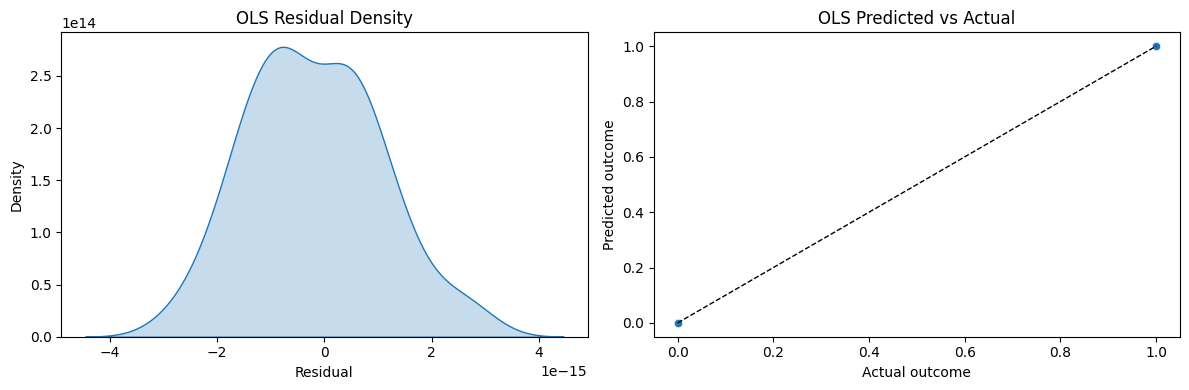

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.kdeplot(residuals_ols, fill=True, ax=axes[0])
axes[0].set_title('OLS Residual Density')
axes[0].set_xlabel('Residual')

sns.scatterplot(x=y, y=y_hat_ols, ax=axes[1])
axes[1].plot([0, 1], [0, 1], linestyle='--', color='black', linewidth=1)
axes[1].set_title('OLS Predicted vs Actual')
axes[1].set_xlabel('Actual outcome')
axes[1].set_ylabel('Predicted outcome')

plt.tight_layout()
plt.show()


The training MSE is essentially zero, which means the linear model interpolates the training data almost perfectly. That is not surprising here because the dataset has far more gene predictors than patient observations, so an unregularized linear model has enough flexibility to memorize the sample.


### 3. Use cross validation to compute the mean squared error of the linear model. Discuss your results from the perspective of the bias variance trade-off.

In [14]:
kfold = KFold(n_splits=5, shuffle=True, random_state=100)
cv_scores = cross_val_score(
    LinearRegression(),
    X,
    y,
    cv=kfold,
    scoring='neg_mean_squared_error'
)
cv_mse = -cv_scores

print('Fold MSE values:', cv_mse)
print(f'Mean CV MSE: {cv_mse.mean():.6f}')
print(f'Median CV MSE: {np.median(cv_mse):.6f}')
print(f'Standard deviation: {cv_mse.std():.6f}')


Fold MSE values: [0.0244198  0.05792023 0.09224999 0.02097934 0.02126042]
Mean CV MSE: 0.043366
Median CV MSE: 0.024420
Standard deviation: 0.028108


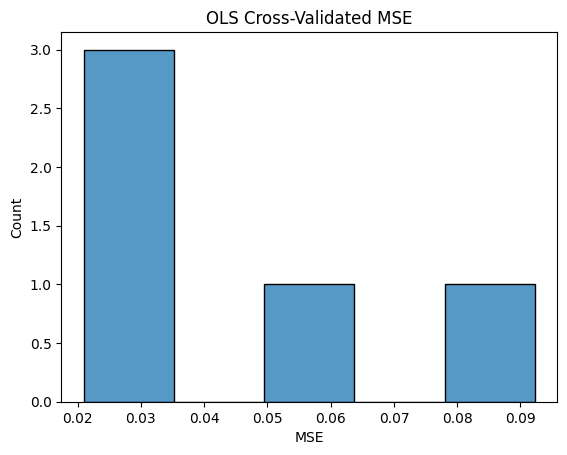

In [15]:
sns.histplot(cv_mse, bins=5)
plt.title('OLS Cross-Validated MSE')
plt.xlabel('MSE')
plt.show()


The contrast between near-zero training error and a noticeably larger cross-validated MSE is a classic high-variance pattern. OLS has very low bias on the training sample, but it is unstable out of sample because it is fitting thousands of genes with only 72 patients. Cross validation shows that the apparent perfect fit does not generalize nearly as well as the training error suggests.


### 4. Use the cross validated LASSO to select a set of highly predictive genes. Which set of genes is selected? How many genes are discarded from the model? Make a scatterplot of your predictions versus the actual values.

In [16]:
scaler = StandardScaler()
X_sc = scaler.fit_transform(X)

alpha_grid = np.logspace(-4, -2, num=50)
lasso_cv = LassoCV(cv=10, alphas=alpha_grid, random_state=100, max_iter=10000)
lasso_cv.fit(X_sc, y)

alpha_star = lasso_cv.alpha_
mean_mse_path = np.mean(lasso_cv.mse_path_, axis=1)
index_star = np.argmin(mean_mse_path)

coefs = []
for alpha in lasso_cv.alphas_:
    model = Lasso(alpha=alpha, max_iter=10000)
    model.fit(X_sc, y)
    coefs.append(model.coef_)
coefs = np.array(coefs)

coefs_star = coefs[index_star]
selected_idx = np.nonzero(coefs_star)[0]
selected_genes = X.columns[selected_idx].tolist()

lasso_star = Lasso(alpha=alpha_star, max_iter=10000).fit(X_sc, y)
y_hat_lasso = lasso_star.predict(X_sc)

print(f'Optimal alpha: {alpha_star:.10f}')
print(f'Selected genes: {len(selected_genes)}')
print(f'Discarded genes: {X.shape[1] - len(selected_genes)}')
selected_genes


Optimal alpha: 0.0006551286
Selected genes: 80
Discarded genes: 7049


['AF000560_at',
 'AF002020_at',
 'AF006087_at',
 'D26579_at',
 'D29956_at',
 'D42043_at',
 'D50840_at',
 'D86982_at',
 'HG2161-HT2231_at',
 'J04101_at',
 'J04164_at',
 'L12723_at',
 'L13848_at',
 'L20941_at',
 'M12759_at',
 'M17754_at',
 'M19507_at',
 'M20902_at',
 'M22960_at',
 'M23197_at',
 'M27891_at',
 'M28713_at',
 'M31994_at',
 'M63138_at',
 'M84526_at',
 'M95178_at',
 'M96326_rna1_at',
 'M98539_at',
 'U10868_at',
 'U14588_at',
 'U30828_at',
 'U34877_at',
 'U36621_cds2_at',
 'U46751_at',
 'U50136_rna1_at',
 'U51127_at',
 'U60062_at',
 'U82313_at',
 'U82759_at',
 'U88666_at',
 'U89942_at',
 'X04143_at',
 'X14789_at',
 'X16706_at',
 'X53331_at',
 'X56741_at',
 'X63753_at',
 'X66533_at',
 'X66867_cds1_at',
 'X69111_at',
 'X81479_at',
 'X83378_at',
 'X95735_at',
 'X96698_at',
 'Y00636_at',
 'Y07604_at',
 'Y07755_at',
 'Y10207_at',
 'Y12670_at',
 'M96843_at',
 'X58072_at',
 'AC002477_s_at',
 'L15326_s_at',
 'X57351_at',
 'K02777_s_at',
 'U37055_rna1_s_at',
 'U59632_s_at',
 'X07438_s_a

The LASSO keeps 80 genes and discards 7,049 genes from the original 7,129 predictors. The selected genes are:

`AF000560_at`, `AF002020_at`, `AF006087_at`, `D26579_at`, `D29956_at`, `D42043_at`, `D50840_at`, `D86982_at`, `HG2161-HT2231_at`, `J04101_at`, `J04164_at`, `L12723_at`, `L13848_at`, `L20941_at`, `M12759_at`, `M17754_at`, `M19507_at`, `M20902_at`, `M22960_at`, `M23197_at`, `M27891_at`, `M28713_at`, `M31994_at`, `M63138_at`, `M84526_at`, `M95178_at`, `M96326_rna1_at`, `M98539_at`, `U10868_at`, `U14588_at`, `U30828_at`, `U34877_at`, `U36621_cds2_at`, `U46751_at`, `U50136_rna1_at`, `U51127_at`, `U60062_at`, `U82313_at`, `U82759_at`, `U88666_at`, `U89942_at`, `X04143_at`, `X14789_at`, `X16706_at`, `X53331_at`, `X56741_at`, `X63753_at`, `X66533_at`, `X66867_cds1_at`, `X69111_at`, `X81479_at`, `X83378_at`, `X95735_at`, `X96698_at`, `Y00636_at`, `Y07604_at`, `Y07755_at`, `Y10207_at`, `Y12670_at`, `M96843_at`, `X58072_at`, `AC002477_s_at`, `L15326_s_at`, `X57351_at`, `K02777_s_at`, `U37055_rna1_s_at`, `U59632_s_at`, `X07438_s_at`, `M12959_s_at`, `M13690_s_at`, `M26708_s_at`, `M84371_rna1_s_at`, `X12876_s_at`, `M31211_s_at`, `U26312_s_at`, `X85116_rna1_s_at`, `HG4518-HT4921_r_at`, `L08010_at`, `U84388_at`, `X06318_at`.


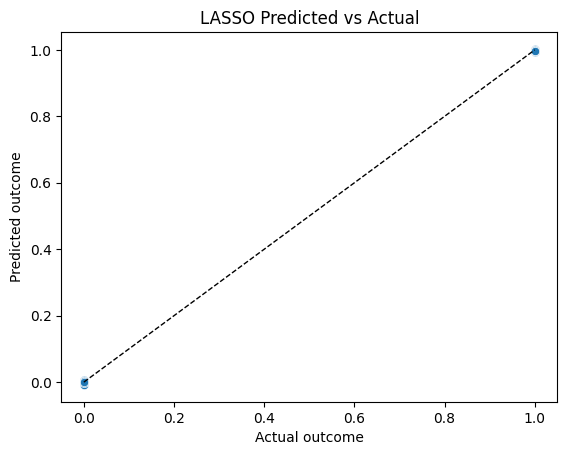

LASSO training MSE: 7.33671e-06


In [17]:
sns.scatterplot(x=y, y=y_hat_lasso)
plt.plot([0, 1], [0, 1], linestyle='--', color='black', linewidth=1)
plt.title('LASSO Predicted vs Actual')
plt.xlabel('Actual outcome')
plt.ylabel('Predicted outcome')
plt.show()

print(f'LASSO training MSE: {mse(y, y_hat_lasso):.6g}')


### 5. Make a plot that shows the cross validated MSE as $alpha$ varies. For what values of $\alpha$ is the LASSO underfitting? Overfitting? What is the optimal penality hyperparameter that minimizes expected MSE?


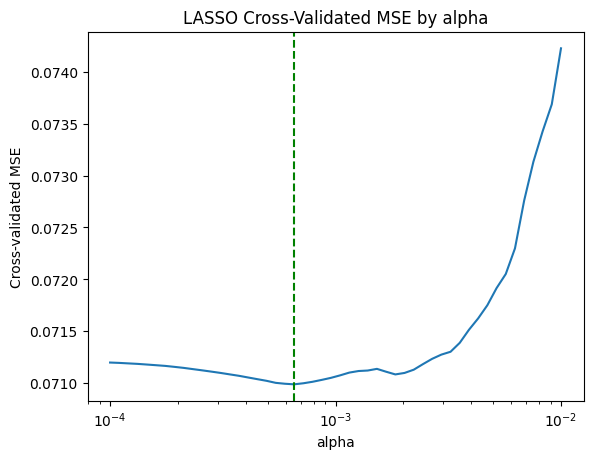

In [18]:
sns.lineplot(x=lasso_cv.alphas_, y=mean_mse_path)
plt.axvline(alpha_star, color='green', linestyle='--', linewidth=1.5)
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('Cross-validated MSE')
plt.title('LASSO Cross-Validated MSE by alpha')
plt.show()


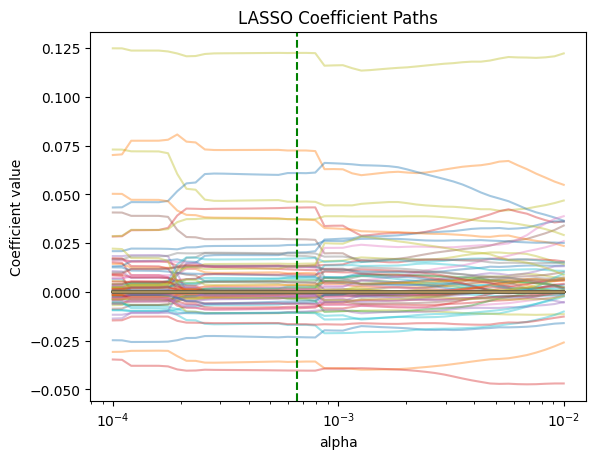

In [19]:
for i in range(coefs.shape[1]):
    plt.plot(lasso_cv.alphas_, coefs[:, i], alpha=0.4)
plt.xscale('log')
plt.axvline(alpha_star, color='green', linestyle='--')
plt.xlabel('alpha')
plt.ylabel('Coefficient value')
plt.title('LASSO Coefficient Paths')
plt.show()


Large values of $\alpha$ on the left side of the plot produce too much shrinkage, so the model underfits there. Very small values of $\alpha$ on the right side of the plot allow too many coefficients back into the model, so that end is the overfitting region. The minimum expected error occurs at approximately $\alpha = 0.0006551286$.


### 6. Explain why linear regression performs perfectly on the training set, but the LASSO provides better predictive performance.


OLS performs perfectly on the training set because this is a high-dimensional setting with many more predictors than observations, so the model has enough flexibility to effectively memorize the sample. That drives the training error to essentially zero, but it also makes the fitted coefficients very sensitive to noise and weak patterns in the data. LASSO predicts better because it shrinks coefficients and sets many of them exactly to zero, which slightly increases bias but greatly reduces variance. In this dataset, that trade-off helps because only a relatively small subset of genes seems to carry most of the signal for separating ALL from AML.

### 7. Why do regularization methods lend themselves to scenarios like precision health?

Precision health settings often involve extremely high-dimensional data, where the number of possible predictors can grow much faster than the number of patients. Humans have around 22,000 to 25,000 genes, and once you start thinking about two-way, three-way, and higher-order interactions, the feature space can become much larger than any realistic genomics dataset can support. In situations like that, regularization methods such as LASSO are useful because they narrow the model down to a smaller subset of genes or interactions that seem most informative. That makes the analysis more statistically manageable and more feasible for follow-up medical testing and genetics research.

### 8. What are the risks of applying methods like the Lasso to precision health questions, where interventions will then be taken to optimize patient health?

The main risk is that these predictions are still only predictive, not causal. The genes selected by LASSO may be strongly associated with an outcome, but that does not mean changing those genes would change the patient’s health in the same way. Gene values are part of a complicated biological system with many simultaneously determined processes, so the selected variables may not lie on a true causal pathway at all. Because of that, using these results to guide pharmaceutical, surgical, or other medical interventions could be risky, since an apparently important gene in the model might just be acting as a marker rather than a true driver of disease.